# The notebook is for reading DTT result from MSNoise and plot dvv 

## Step 0. Import modules and set parameters

In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

plot_case_lst = ['M', 'M0']

# --- parameters free to change ---
project_path = '.'
study_area = 'Mt Etna'
station_pair='IV_EPIT_IV_EMCN'
station_pair = 'ALL'
filter_id = 1
stack_days = 21
component_list = ['EE', 'EN', 'EZ', 'NE', 'NN', 'NZ', 'ZE', 'ZN', 'ZZ']
plot_case = plot_case_lst[1]

In [9]:
def moving_average(data, window_size=30):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

def load_msnoise_DTT(project_path, filter_id=1, stack_days=30, comp_lst=['ZZ'], station_pair='ALL'):
    required_cols = ["Date", "Pairs", "M", "M0"]
    M_sum_dic = {}
    M0_sum_dic = {}
    M_count_dic = {}
    M0_count_dic = {}

    for comp in comp_lst:
        folder = f'{project_path}/DTT/{filter_id:02d}/{stack_days:03d}_DAYS/{comp}'

        if not os.path.isdir(folder):
            print(f"Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(folder) if f.endswith(".txt")]

        for file in files:
            filepath = os.path.join(folder, file)
            df = pd.read_csv(filepath)

            if not all(col in df.columns for col in required_cols):
                print(f"Missing columns in {file}: {df.columns.tolist()}")
                continue

            if df.empty:
                print(f"No data in {file}")
                continue

            # --- Select data ---
            if station_pair == "ALL":
                df_selected = df[df["Pairs"] == "ALL"]

                if df_selected.empty:
                    # If no ALL row exists, average all station pairs
                    Date = pd.to_datetime(df["Date"]).iloc[0]

                    M = -100 * df["M"].astype(float).mean()
                    M0 = -100 * df["M0"].astype(float).mean()
                else:
                    Date = pd.to_datetime(df_selected["Date"]).iloc[0]

                    M = -100 * float(df_selected["M"].iloc[0])
                    M0 = -100 * float(df_selected["M0"].iloc[0])
            else:
                # Try requested station pair
                df_selected = df[df["Pairs"] == station_pair]

                # If not found, try reversed station order
                if df_selected.empty:
                    try:
                        nw1, st1, nw2, st2 = station_pair.split("_")
                    except ValueError:
                        raise ValueError(
                            "station_pair must have the format "
                            "'NW1_STA1_NW2_STA2', e.g. 'BK_BKS_BK_BRK'"
                        )

                    station_pair_reverse = (f"{nw2}_{st2}_{nw1}_{st1}")

                    df_selected = df[df["Pairs"] == station_pair_reverse]

                # Neither direction exists in this file
                if df_selected.empty:
                    continue

                Date = pd.to_datetime(df_selected["Date"]).iloc[0]

                M = -100 * float(df_selected["M"].iloc[0])
                M0 = -100 * float(df_selected["M0"].iloc[0])

            # --- Accumulate values across components ---
            if Date not in M_sum_dic:
                M_sum_dic[Date] = 0
                M_count_dic[Date] = 0

            M_sum_dic[Date] += M
            M_count_dic[Date] += 1

            if Date not in M0_sum_dic:
                M0_sum_dic[Date] = 0
                M0_count_dic[Date] = 0

            M0_sum_dic[Date] += M0
            M0_count_dic[Date] += 1

    # --- Combine all dates from all components ---
    date_lst = sorted(M_sum_dic.keys())

    M_lst = np.array([M_sum_dic[date]/M_count_dic[date] for date in date_lst])
    M0_lst = np.array([M0_sum_dic[date]/M0_count_dic[date] for date in date_lst])

    # --- Smooth ---
    M_lst_smooth = moving_average(M_lst, window_size=30)
    M0_lst_smooth = moving_average(M0_lst, window_size=30)

    return date_lst, M_lst, M0_lst, M_lst_smooth, M0_lst_smooth

In [10]:
date_lst, M_lst, M0_lst, M_lst_smooth, M0_lst_smooth = load_msnoise_DTT(project_path, filter_id, stack_days, component_list, station_pair)

In [11]:
def plot_dvv(study_area, plot_case, station_pair, date_lst, M_lst, M0_lst, M_lst_smooth, M0_lst_smooth):
    fig = plt.figure(figsize=(12, 4))
    if plot_case == 'M':
        plt.scatter(date_lst, M_lst, color='orange', s=3, label=f'M')
        plt.scatter(date_lst, M_lst_smooth, color='r', s=3, label=f'M (smoothed)')
    elif plot_case == 'M0':
        plt.scatter(date_lst, M0_lst, color='grey', s=3, label=f'M0')
        plt.scatter(date_lst, M0_lst_smooth, color='k', s=3, label=f'M0 (smoothed)')

    plt.xlabel('Date')
    plt.ylabel('dv/v (%)')

    plt.title(f'dv/v at {study_area} (Station Pair: {station_pair})')
    plt.xlim(date_lst[0], date_lst[-1])
    plt.gca().invert_yaxis()
    plt.legend()
    plt.show()

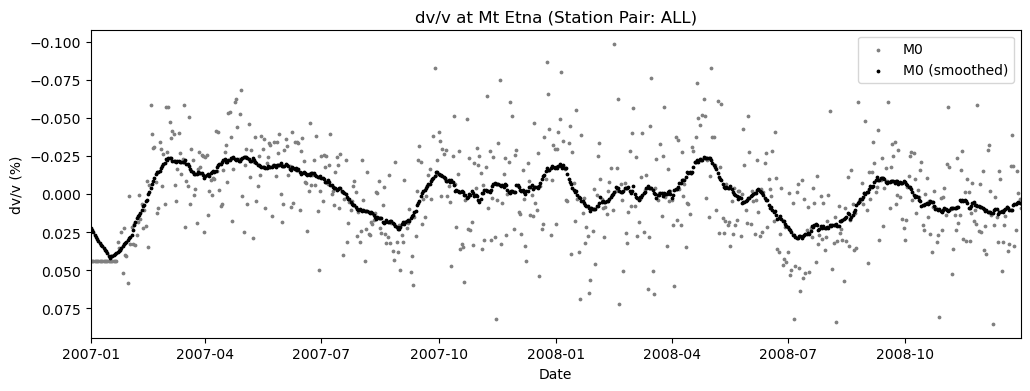

In [12]:
plot_dvv(study_area, plot_case, station_pair, date_lst, M_lst, M0_lst, M_lst_smooth, M0_lst_smooth)